<a href="https://colab.research.google.com/github/ciril7/AI-ML-Intern/blob/main/Day%202/House%20price%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import sklearn.preprocessing

In [ ]:
df=pd.read_csv('/content/boston.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
encoder_data=df.copy()

In [ ]:
df['age_mean_imputed']=df['age'].fillna(df['age'])

In [ ]:
df['age_median_imputed']=df['age'].fillna(df['age'].median())

In [ ]:
df['tax_mode_imputed']=df['tax'].fillna(df['tax'].mode()[0])

In [ ]:
df[['age','age_mean_imputed','age_median_imputed']]

,age,age_mean_imputed,age_median_imputed
0,65.2,65.2,65.2
1,78.9,78.9,78.9
2,61.1,61.1,61.1
3,45.8,45.8,45.8
4,54.2,54.2,54.2
...,...,...,...
501,69.1,69.1,69.1
502,76.7,76.7,76.7
503,91.0,91.0,91.0
504,89.3,89.3,89.3


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
sns.set(style="whitegrid")

/tmp/ipykernel_21922/3183086075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='rad',y='ptratio',palette='Set3')


Text(0, 0.5, 'ptratio')

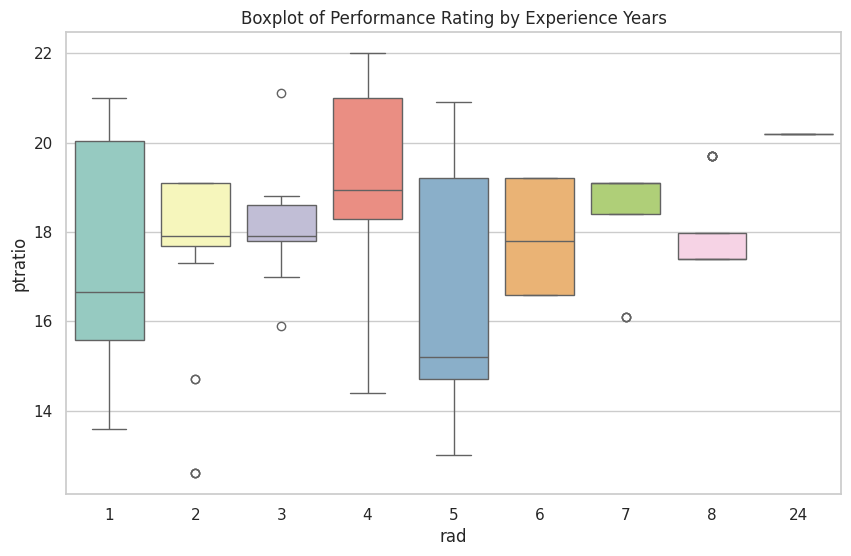

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='rad',y='ptratio',palette='Set3')
plt.title('Boxplot of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_21922/4240688216.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

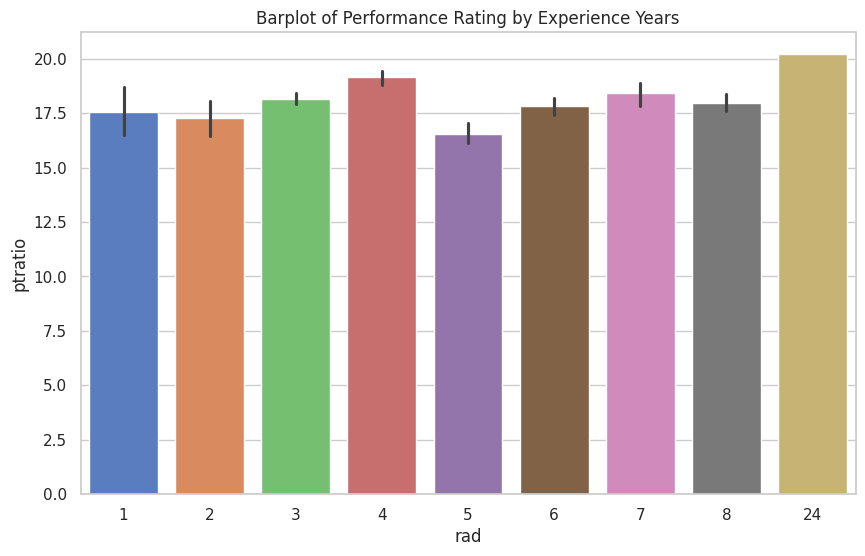

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Barplot of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_21922/97058352.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

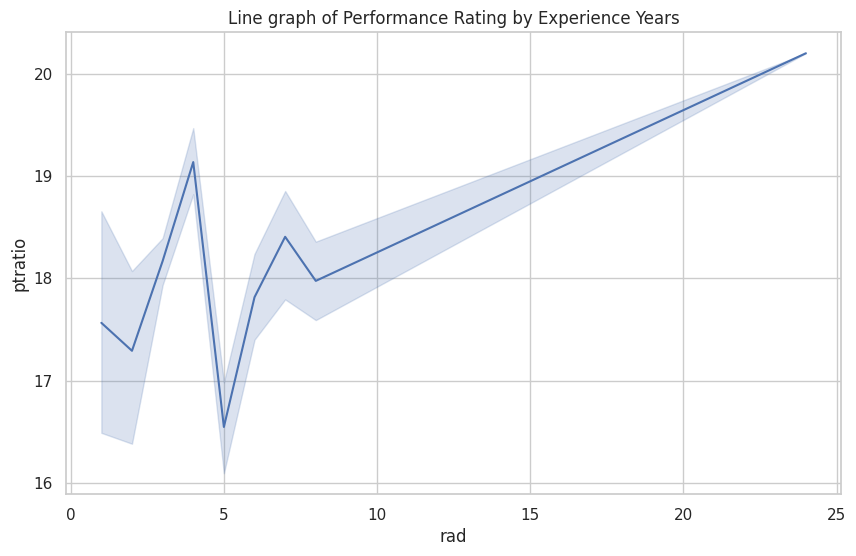

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Line graph of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_21922/2917517358.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

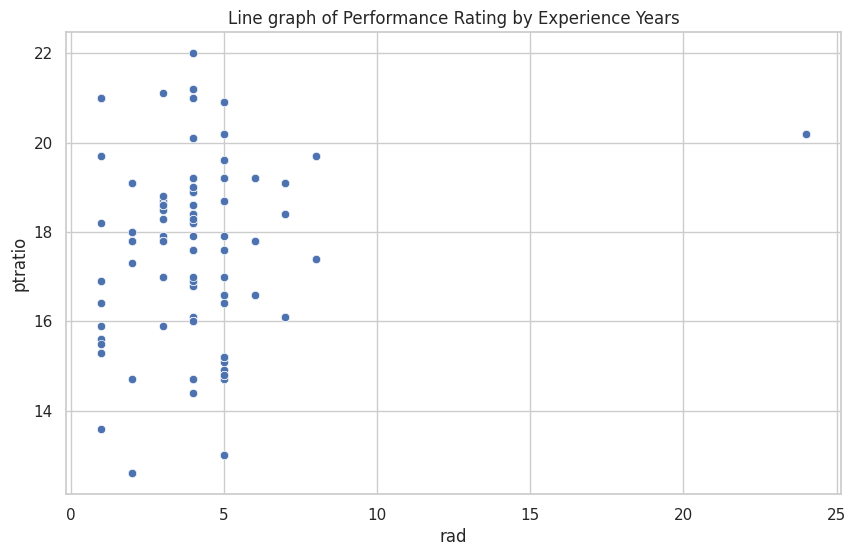

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Line graph of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_21922/3497667214.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

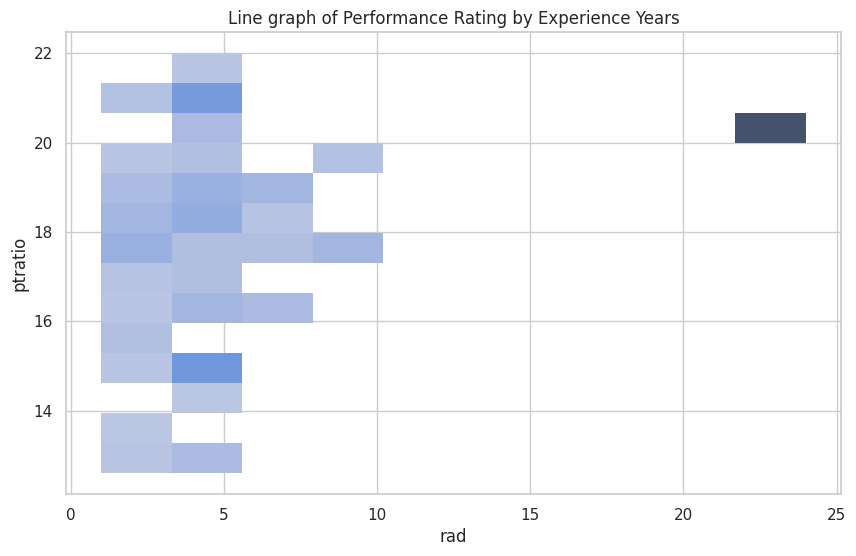

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Line graph of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

In [ ]:
encoded_data=df.copy()

In [ ]:
one_hot_encoded = pd.get_dummies(encoded_data['rad'], prefix='rad')
encoded_data = pd.concat([encoded_data, one_hot_encoded], axis=1)

ptratio_mapping = {1: 'First', 2: 'Second', 3: 'Third', 4: 'Fourth',5:'Fifth'}
encoded_data['ptratio_Category'] = encoded_data['ptratio'].map(ptratio_mapping)

print(encoded_data[['age', 'rad', 'ptratio', 'ptratio_Category']].head())

    age  rad  ptratio ptratio_Category
0  65.2    1     15.3              NaN
1  78.9    2     17.8              NaN
2  61.1    2     17.8              NaN
3  45.8    3     18.7              NaN
4  54.2    3     18.7              NaN


In [ ]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler

In [ ]:
numerical_columns=['age','ptratio']

In [ ]:
df.dropna(subset=numerical_columns,inplace=True)

In [ ]:
minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()
robust_scaler=RobustScaler()

In [ ]:
df['age_MinMax']=minmax_scaler.fit_transform(df[['age']])
df['ptratio_MinMax']=minmax_scaler.fit_transform(df[['ptratio']])

In [ ]:
df['age_Standard']=minmax_scaler.fit_transform(df[['age']])
df['ptratio_Standard']=minmax_scaler.fit_transform(df[['ptratio']])

In [ ]:
df['age_Robust']=minmax_scaler.fit_transform(df[['age']])
df['ptratio_Robust']=minmax_scaler.fit_transform(df[['ptratio']])

In [ ]:
df[['age','age_MinMax','age_Standard','age_Robust']]

,age,age_MinMax,age_Standard,age_Robust
0,65.2,0.641607,0.641607,0.641607
1,78.9,0.782698,0.782698,0.782698
2,61.1,0.599382,0.599382,0.599382
3,45.8,0.441813,0.441813,0.441813
4,54.2,0.528321,0.528321,0.528321
...,...,...,...,...
501,69.1,0.681771,0.681771,0.681771
502,76.7,0.760041,0.760041,0.760041
503,91.0,0.907312,0.907312,0.907312
504,89.3,0.889804,0.889804,0.889804


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
X=df.drop(columns=["medv"])

In [ ]:
Y=df["medv"]

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
Y_pred=model.predict(X_test)

In [ ]:
r2=r2_score(Y_test,Y_pred)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

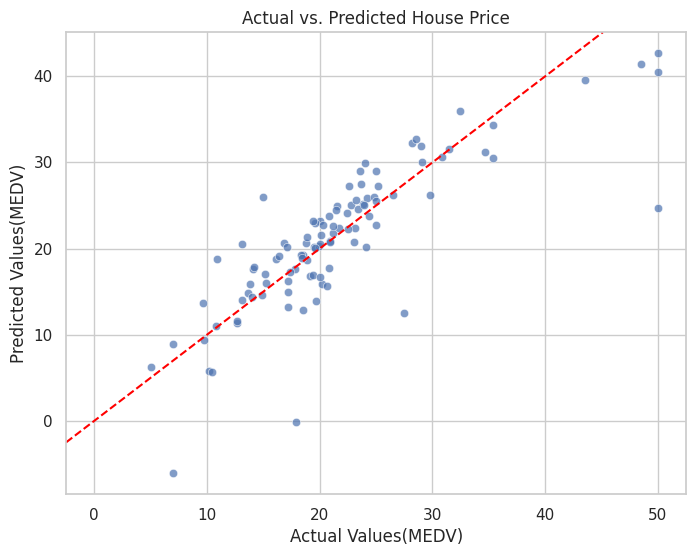

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(MEDV)')
plt.ylabel('Predicted Values(MEDV)')
plt.title('Actual vs. Predicted House Price')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show

In [ ]:
from scipy.stats import skew

In [ ]:
skewness=df.skew()

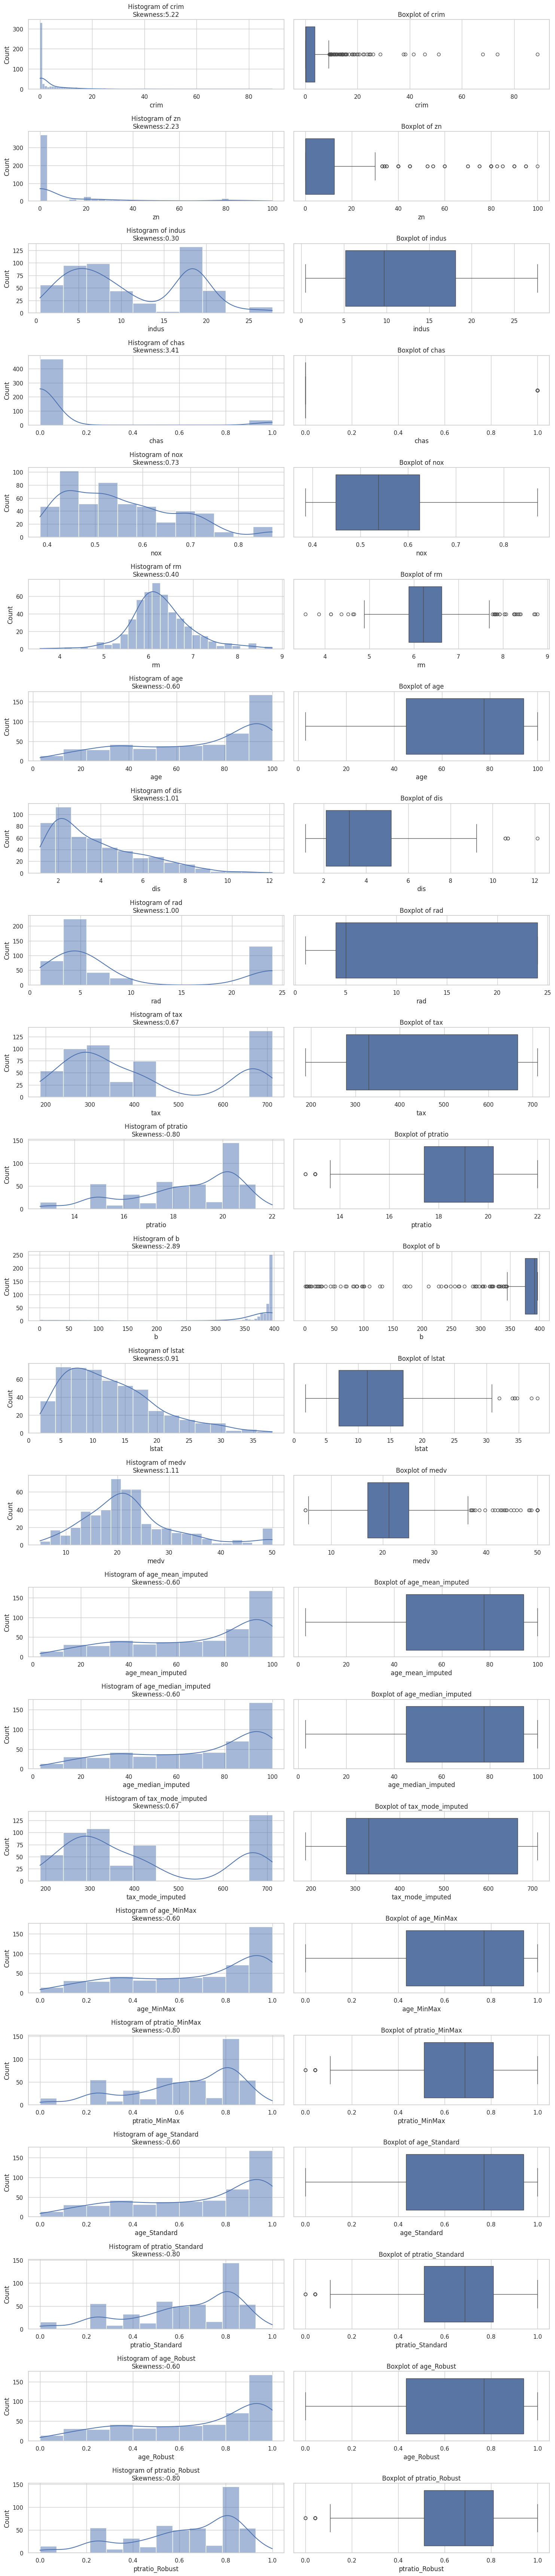

In [ ]:
num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))
for i,col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f'Histogram of {col}\nSkewness:{skewness[col]:.2f}')

  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
skewness=df.skew()
print(skewness)

crim                  5.223149
zn                    2.225666
indus                 0.295022
chas                  3.405904
nox                   0.729308
rm                    0.403612
age                  -0.598963
dis                   1.011781
rad                   1.004815
tax                   0.669956
ptratio              -0.802325
b                    -2.890374
lstat                 0.906460
medv                  1.108098
age_mean_imputed     -0.598963
age_median_imputed   -0.598963
tax_mode_imputed      0.669956
age_MinMax           -0.598963
ptratio_MinMax       -0.802325
age_Standard         -0.598963
ptratio_Standard     -0.802325
age_Robust           -0.598963
ptratio_Robust       -0.802325
dtype: float64


In [ ]:
import numpy as np
skewed_cols=df.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')
Negatively Skewed Columns:
 Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat',
       'age_mean_imputed', 'age_median_imputed', 'tax_mode_imputed',
       'age_MinMax', 'ptratio_MinMax', 'age_Standard', 'ptratio_Standard',
       'age_Robust', 'ptratio_Robust'],
      dtype='object')


In [ ]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7633
RMSE: 0.1812


In [ ]:
df.skew()

,0
crim,1.269201
zn,1.193451
indus,-0.104641
chas,3.405904
nox,0.098431
rm,0.023275
age,-0.417736
dis,0.331561
rad,0.532760
tax,0.079613


<function matplotlib.pyplot.show(close=None, block=None)>

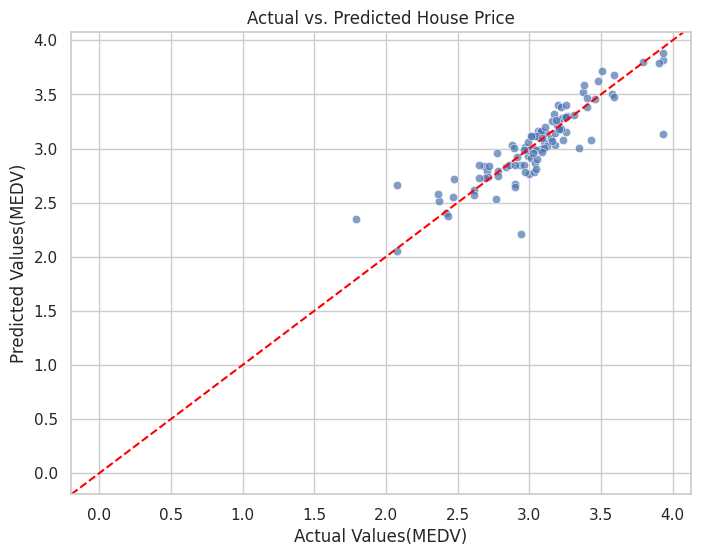

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(MEDV)')
plt.ylabel('Predicted Values(MEDV)')
plt.title('Actual vs. Predicted House Price')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print(f"Random Forest R² Score: {r2:.4f}")
print(f"Random Forest RMSE: {rmse:.4f}")

Random Forest R² Score: 0.8396
Random Forest RMSE: 0.1492


<function matplotlib.pyplot.show(close=None, block=None)>

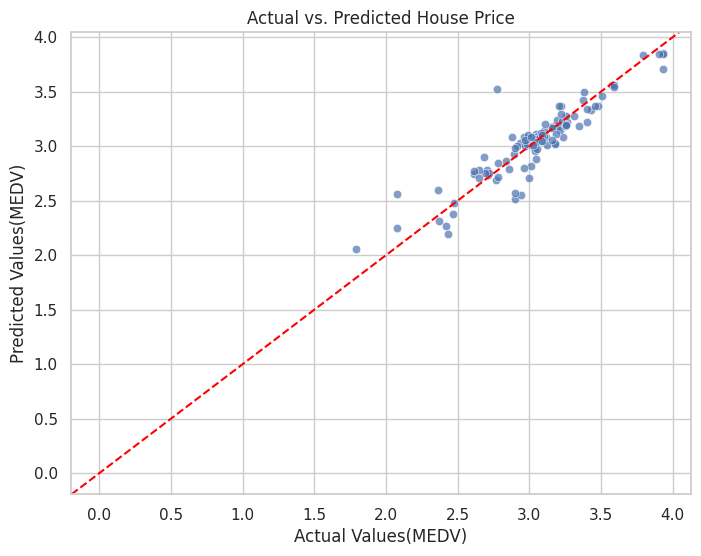

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(MEDV)')
plt.ylabel('Predicted Values(MEDV)')
plt.title('Actual vs. Predicted House Price')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show